<a href="https://colab.research.google.com/github/Atharva-Gaykar/Inter_IIIT/blob/main/Fine_tune_DistilBert_For_Embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.model_selection import train_test_split
from datasets import Dataset
import torch
import pandas as pd

# --------------------------
# 1️⃣  Create a small toy dataset
# --------------------------
data = {
    "text_combined": [
        "[SSUB] Meeting Reminder [ESUB] [SBODY] Please join at 3PM. [EBODY]",
        "[SSUB] Urgent Account Alert [ESUB] [SBODY] Click [LINK] to verify. [EBODY]",
        "[SSUB] Invoice Attached [ESUB] [SBODY] Please see attached file. [EBODY]",
        "[SSUB] Lottery Win [ESUB] [SBODY] Call [PHONE] to claim. [EBODY]"
    ],
    "label": [0, 1, 2, 3]  # 0=safe, 1=phishing, 2=malicious, 3=spam
}

df = pd.DataFrame(data)
train_df, test_df = train_test_split(df, test_size=0.25, random_state=42)

# Convert to HF Datasets
train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_df)

# --------------------------
# 2️⃣  Load tokenizer & add special tokens
# --------------------------
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)

special_tokens = {
    "additional_special_tokens": [
        "[SSUB]", "[ESUB]", "[SBODY]", "[EBODY]", "[LINK]", "[PHONE]"
    ]
}
num_added = tokenizer.add_special_tokens(special_tokens)
print(f"Added {num_added} new tokens.")

# --------------------------
# 3️⃣  Tokenize dataset
# --------------------------
def preprocess_function(examples):
    return tokenizer(
        examples["text_combined"],
        truncation=True,
        padding="max_length",
        max_length=128,
    )

train_ds = train_ds.map(preprocess_function, batched=True)
test_ds = test_ds.map(preprocess_function, batched=True)

train_ds = train_ds.rename_column("label", "labels")
test_ds = test_ds.rename_column("label", "labels") # Add this line
train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# --------------------------
# 4️⃣  Load model & resize embeddings
# --------------------------
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=4)
model.resize_token_embeddings(len(tokenizer))

# --------------------------
# 5️⃣  Training setup
# --------------------------
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilbert_phishing_toy",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_strategy="steps",
    push_to_hub=False,
    load_best_model_at_end=True,
    logging_steps=10,

    # <-- disable external reporters (WandB, TensorBoard, etc.)
    report_to=["none"],   # or report_to=[]
)


# --------------------------
# 6️⃣  Define Trainer
# --------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
)

# --------------------------
# 7️⃣  Fine-tune
# --------------------------
trainer.train()

# --------------------------
# 8️⃣  Evaluate
# --------------------------
results = trainer.evaluate()
print("\n📊 Evaluation results:", results)

# --------------------------
# 9️⃣  Inference on new text
# --------------------------
text = "[SSUB] Security Update [ESUB] [SBODY] Click [LINK] to reset your password. [EBODY]"
inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    logits = model(**inputs).logits
pred_label = torch.argmax(logits, dim=1).item()

print(f"\nPredicted label: {pred_label}")

Added 6 new tokens.


Map:   0%|          | 0/3 [00:00<?, ? examples/s]

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1446220208.py:99: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss
1,No log,1.466903
2,No log,1.506728
3,No log,1.530587


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



📊 Evaluation results: {'eval_loss': 1.4669026136398315, 'eval_runtime': 0.2425, 'eval_samples_per_second': 4.123, 'eval_steps_per_second': 4.123, 'epoch': 3.0}

Predicted label: 3


Start from here

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

text_df = pd.read_csv('/content/drive/MyDrive/Bert_Data.csv')
display(text_df.head())

,text_combined,label
0,[SSUB] CNN.com Daily Top 10 [ESUB] [SBODY] >+=...,1
1,[SSUB] [ILUG] What to do when the stock market...,1
2,[SSUB] Upcoming Workshop [ESUB] [SBODY] Join o...,0
3,[SSUB] Virtueller Messetag der jobfair24 am Mi...,0
4,[SSUB] Meet other Singles just like you [ESUB]...,1


In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertModel
import torch

model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)

from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

# 2) special tokens we want to add
special_tokens = {
    "additional_special_tokens": [
        "[SSUB]", "[ESUB]", "[SBODY]", "[EBODY]", "[LINK]", "[PHONE]"
    ]
}

#this step is done to add our custom tokens
num_added = tokenizer.add_special_tokens(special_tokens)
print(f"Added {num_added} special tokens to tokenizer.")


model.resize_token_embeddings(len(tokenizer))
print(f"Resized model embeddings to vocab size: {len(tokenizer)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Added 6 special tokens to tokenizer.
Resized model embeddings to vocab size: 30528


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"✅ Model running on device: {device}")

✅ Model running on device: cuda


In [ ]:
from datasets import Dataset


dataset = Dataset.from_pandas(text_df)
display(dataset)

Dataset({
    features: ['text_combined', 'label'],
    num_rows: 43006
})

In [ ]:
train_val_test = dataset.train_test_split(test_size=0.2, seed=42)


val_test = train_val_test['test'].train_test_split(test_size=0.5, seed=42)


train_dataset = train_val_test['train']
val_dataset = val_test['train']
test_dataset = val_test['test']


In [ ]:
def preprocess_function(examples):
    return tokenizer(
        examples["text_combined"],
        truncation=True,
        padding="max_length",
        max_length=256
    )


In [ ]:
train_dataset = train_dataset.map(preprocess_function, batched=True)
val_dataset = val_dataset.map(preprocess_function, batched=True)
test_dataset = test_dataset.map(preprocess_function, batched=True)

train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/34404 [00:00<?, ? examples/s]

Map:   0%|          | 0/4301 [00:00<?, ? examples/s]

Map:   0%|          | 0/4301 [00:00<?, ? examples/s]

In [ ]:
for name, param in model.distilbert.transformer.layer[:5].named_parameters():
    param.requires_grad = False


total, trainable = 0, 0
for name, param in model.named_parameters():
    total += param.numel()
    if param.requires_grad:
        trainable += param.numel()

print(f"Total parameters: {total:,}")
print(f"Trainable parameters: {trainable:,} ({trainable/total:.2%})")

Total parameters: 66,959,618
Trainable parameters: 31,520,258 (47.07%)


In [ ]:
from transformers import TrainingArguments, Trainer

In [ ]:
training_args = TrainingArguments(
    output_dir="./distilbert_safe_suspicious",
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    learning_rate=4e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01,
    report_to=[],
    logging_strategy="steps",
    logging_steps=50,
    seed=42,
)


In [ ]:
from transformers import EarlyStoppingCallback

In [ ]:

early_stopping = EarlyStoppingCallback(
    early_stopping_patience=2
)

In [ ]:


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    callbacks=[early_stopping],

)


/tmp/ipython-input-3606388456.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

Step,Training Loss,Validation Loss
50,0.426200,0.169218
100,0.156300,0.115954
150,0.084500,0.091472
200,0.100100,0.072179
250,0.116200,0.056544
300,0.064500,0.064856


Step,Training Loss,Validation Loss
50,0.426200,0.169218
100,0.156300,0.115954
150,0.084500,0.091472
200,0.100100,0.072179
250,0.116200,0.056544
300,0.064500,0.064856
350,0.081600,0.041448
400,0.080900,0.031734
450,0.067400,0.029636
500,0.066000,0.036241


TrainOutput(global_step=550, training_loss=0.11694279193878174, metrics={'train_runtime': 542.4851, 'train_samples_per_second': 253.677, 'train_steps_per_second': 15.86, 'total_flos': 582856554086400.0, 'train_loss': 0.11694279193878174, 'epoch': 0.2556950255695026})

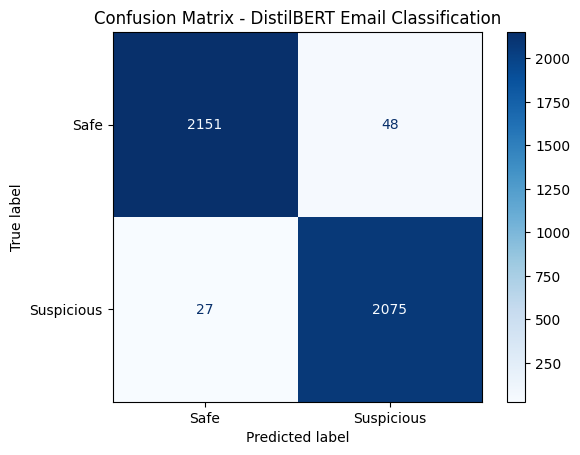

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions
predictions = trainer.predict(test_dataset)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Safe", "Suspicious"])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix - DistilBERT Email Classification")
plt.show()


In [ ]:
save_path = "/content/drive/MyDrive/DistilBert_Finetuned"


model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print("✅ Directly saved current model and tokenizer to Drive.")


✅ Directly saved current model and tokenizer to Drive.


In [ ]:
import torch
import numpy as np

# Function to get the CLS (sentence-level) embedding for one text
def get_cls_embedding(text, model, tokenizer, device):
    model.eval()
    with torch.no_grad():
        # Tokenize input
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=256
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Get last hidden state (DistilBERT output)
        outputs = model.distilbert(**inputs)

        # CLS embedding = first token of last hidden state
        cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()
    return cls_embedding


In [ ]:
text = "[SSUB] Urgent Account Alert [ESUB] [SBODY] Click [LINK] to verify your account. [EBODY]"
embedding = get_cls_embedding(text, model, tokenizer, device)

print("✅ Embedding shape:", embedding.shape)
print("First 10 dimensions:", embedding[:10])


✅ Embedding shape: (768,)
First 10 dimensions: [-0.5912518  -0.0652531   0.8044254  -0.1458979   0.52833486 -1.0552992
  1.2237177   0.6522493   0.13072713 -0.26956698]
